# Import

In [1]:
import ROOT as r
import fedrarootlogon 
from matplotlib import pyplot as plt
import matplotlib
import awkward as ak
import uproot
import numpy as np
import time

import sys
sys.path.insert(0, "/home/baronunix/Scripts/")
from Clustering_Cosmici_Frammenti import *

def g_func(x, p1, p2, p3):
    return p1* np.exp(- (x - p2)**2 / (2*p3**2) )

%jsroot on 
track_name = "b000444.2.0.0.trk.root"
file_name = "~/Scripts/GSI4/b44_vol.root"
file_name_cuts = "~/Scripts/GSI4/b44_vol_cuts.root"
brick_id = "GSI4"

k0_min = 3
k_stat = 1
outname = "output_b444_NEW_k0min"+str(k0_min)+".root"
VR0_max = 25000

file_name01 = '01.root'
tup_name01 = '01_c'
file_name012 = '012.root'
tup_name012 = '012_c'
file_name123 = '123.root'
tup_name123 = '123_c'
file_name013 = '013.root'
tup_name013 = '013_c'

Welcome to JupyROOT 6.26/06
Load FEDRA libs


# Calcolo Variabili di Volume

In [2]:
#Calcolo_Variabili_Volume_New(file_name, track_name)

1

# Taglio su k0

In [3]:
file = r.TFile(file_name, "READ")
tracks_V = file.Get("tracks_n")
r.gStyle.SetOptStat(1111)

In [4]:
file2 = r.TFile(file_name_cuts, "RECREATE")
t_tracks_V = tracks_V.CopyTree("k0>=" + str(k0_min) + " && VR0_av<"+str(VR0_max))
t_tracks_V.Write("tracks_cuts")
file2.Close()

file.Close()

In [5]:
file2 = r.TFile(file_name_cuts, "READ")

tracks_2 = file2.Get("tracks_cuts")

c = r.TCanvas()
tracks_2.Draw("VR0_av:tanf>>vr0_tan(100, 0,1, 100, 0, 20000)", "", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta) [k_{0}>= "+ str(k0_min) + "]; tan(#theta); VR0_{av}")
vr0_tan.Draw("COLZ")
c.Draw()
r.gPad.Update()
st = vr0_tan.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
t1 = r.TText(c.GetUxmax()/15, 2000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [6]:
a2, b2 = 2200, 0.85  #2400, 0.95 x k0>=4
c2, d2 = 100, .45
frag_cut2 = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"
frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"
nfrag_cut = "VR0_av < " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"
nfrag_cut2 = "VR0_av < " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"


c = r.TCanvas()
tracks_2.Draw("VR0_av:tanf>>vr0_tan(100, 0,1, 100, 2000, 20000)", "", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta) [k_{0}>="+str(k0_min)+"]; tan(#theta); VR0_{av}")
vr0_tan.Draw("COLZ")

N_tot = vr0_tan.GetEntries()

cut_curve3 = r.TF1("cut_med", str(a2)+"*(1 + exp("+str(b2)+ " *x*x)) - " + str(c2) + "*exp(1/" + str(d2) + "*x)", 0, 1)
cut_curve3.SetLineColor(8)
cut_curve3.SetLineWidth(3)
#cut_curve3.Draw("SAME")

cut_curve2 = r.TF1("cut_bk", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
cut_curve2.Draw("SAME")

r.gPad.Update()
st = vr0_tan.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(c.GetUxmax()/15, 2500, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

# VR1 vs VR0

In [7]:
c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>hprot", frag_cut, "COLZ")

hprot = r.gDirectory.Get("hprot")
hprot.SetTitle("VR1_{av} vs VR0_{av} [Frag_Cut];VR0_{av};VR1_{av}")
c.Draw()
st = hprot.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(6000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [8]:
c = r.TCanvas()

cond = " && VR1_av>0" 

tracks_2.Draw("VR1_av:VR0_av>>vr1_vr0", 
                  frag_cut + cond, "COLZ")
h4 = r.gDirectory.Get("vr1_vr0")
h4.SetTitle("VR1_{av} vs VR0_{av} [Frag_Cut & VR1_{av}>0];VR0_{av};VR1_{av}")
h4.Draw("colz")
c.Draw()
st = h4.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
t1 = r.TText(6000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")


c.Draw()

# VR3, VR2, VR1

In [9]:
c2 = r.TCanvas()

cond = " && VR1_av>0 && k2>1 && k3>1" 
#new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond
new_cut2 = frag_cut + cond

tracks_2.Draw("VR2_av:VR1_av>>vr21", 
                  new_cut2, "COLZ")
h53 = r.gDirectory.Get("vr21")
h53.SetTitle("VR2_{av} vs VR1_{av} [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}>1];VR1_{av};VR2_{av}")
h53.Draw("COLZ")
c2.Draw()
st = h53.FindObject("stats")
st.SetX1NDC(0.10)
st.SetX2NDC(0.50)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(2000, 4000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c2.Draw()

In [10]:
c2 = r.TCanvas()

cond = " && VR1_av>0 && k2>1 && k3>1" 
#new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond
new_cut2 = frag_cut + cond

tracks_2.Draw("VR3_av:VR2_av>>vr32", 
                  new_cut2, "COLZ")
h53 = r.gDirectory.Get("vr32")
h53.SetTitle("VR3_{av} vs VR2_{av} [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}>1];VR2_{av};VR3_{av}")
h53.Draw("COLZ")
c2.Draw()
st = h53.FindObject("stats")
st.SetX1NDC(0.10)
st.SetX2NDC(0.50)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(2000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c2.Draw()

In [11]:
c2 = r.TCanvas()

cond = " && VR1_av>0 && k2>1 && k3>1" 
new_cut2 = frag_cut + cond

tracks_2.Draw("VR3_av:VR2_av>>vr32(60, 1000, 10500, 60, 1000 ,10500)", 
                  new_cut2, "COLZ")
h53 = r.gDirectory.Get("vr32")
h53.SetTitle("VR3_{av} vs VR2_{av} [Close-Up, k_{2}, k_{3}>1];VR2_{av};VR3_{av}")
h53.Draw("COLZ")
c2.Draw()
st = h53.FindObject("stats")
st.SetX1NDC(0.10)
st.SetX2NDC(0.50)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(2000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c2.Draw()

# VP123

In [12]:
file_pca = r.TFile("PCA_123.root", "RECREATE")

cond = " && k1>0 && k2>1 && k3>1"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()

In [13]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_123.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR1_av, track.VR2_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [14]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI4/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [15]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR1_av, track.VR2_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123, vr123b = [], []
for i in vr123s:
    vr123.append(i[0])
    vr123b.append(i[1])
    
file_pca.Close()

In [16]:
file_pca_2 = r.TFile("PCA2.root", "RECREATE")

pca_1 = r.TNtuple("pca_1", "", "VR123:VR123b")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i], vr123b[i])

In [17]:
kn = r.TCanvas()
pca_1.Draw("VR123>>123(100, -10, 5.5)")

hi = r.gDirectory.Get("123")
hi.SetTitle("VP_{123} [Frag_Cut & k_{1}>0 & k_{2}, k_{3}>1]; VP_{123}; Entries")
hi.Draw("")

t1 = r.TText(-6., 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

kn.Draw()

In [18]:
pca_1.Write("pca_123")
file_pca = r.TFile("PCA_123.root", "READ")
info_pca = file_pca.Get("pca")
info_pca.AddFriend(pca_1)

In [19]:
c = r.TCanvas()
info_pca.Draw("VR123>>zoom1(100, -10.5, -0.5)", "", "colz")

z1 = r.gDirectory.Get("zoom1")
z1.SetTitle("VP_{123} [Close-up: VP_{123}<-0.5]; VP_{123}; Entries")
z1.Draw()

t1 = r.TText(-6., 40, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [20]:
c = r.TCanvas()
info_pca.Draw("VR123>>histo123(100)", "", "colz")

h123 = r.gDirectory.Get("histo123")
h123.SetTitle("VP_{123} (Frag_Cut, k_{1}>0, k_{2}, k_{3}>1);VP_{123};Entries")

r.gStyle.SetOptStat(0)
g1 = r.TF1("g1", "gaus(0) + gaus(3) + gaus(6) + gaus(9) + gaus(12) + gaus(15)", -10.5, 2.)
g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
g1.SetParameter(11, 0.2)
g1.SetParameter(12, 80)
g1.SetParameter(13, -0.35)
g1.SetParameter(14, 0.5)
g1.SetParameter(15, 2500)
g1.SetParameter(16, .5)
g1.SetParameter(17, 0.8)
#g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
g1.SetLineWidth(2)

h123.Fit("g1", "L","", -10.5, 2.)
#c.Update()
h123.Draw("PE")

params = g1.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) 
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)  #r.kCyan+2
comp1.SetLineStyle(2)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=5
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineStyle(2)
comp2.SetLineColor(95) #r.kGreen+2
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #shoulder
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(8)  #r.kOrange
comp3.SetLineStyle(2)
comp3.Draw("SAME")

comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=2
comp4.SetParameters(params[9], params[10], params[11])
comp4.SetLineColor(r.kPink+3)
comp4.SetLineStyle(2)
comp4.Draw("SAME")

comp5 = r.TF1("comp5", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=3
comp5.SetParameters(params[12], params[13], params[14])
comp5.SetLineColor(r.kMagenta)
comp5.SetLineWidth(2)
comp5.Draw("SAME")

comp6 = r.TF1("comp6", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=4
comp6.SetParameters(params[15], params[16], params[17])
comp6.SetLineColor(r.kCyan+2)
comp6.SetLineStyle(2)
comp6.Draw("SAME")

comps = [comp1, comp2, comp3, comp4, comp5, comp6]
for comp in comps:
    comp.SetLineStyle(9)

legend = r.TLegend(0.4,0.65,0.68,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry("fit", "#splitline{Prob = " + str(round(g1.GetProb(),2))  +"}{#chi^{2}/NDF =" + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF())  +"}" )
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z = 4")
legend.AddEntry(comp4, "Z = 5")
legend.AddEntry(comp5, "Z >=6")
legend.AddEntry(comp6, "Z >=6")
legend.Draw("SAME")

legend2 = r.TLegend(0.15,0.7,0.4,0.85)
legend2.SetTextFont(0)
legend2.SetTextSize(0.04)
legend2.AddEntry("Entries", str("Entries = "+str(hi.GetEntries())), "" )
legend2.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF()), "" )
legend2.AddEntry("prob", "Prob = " + str(round(g1.GetProb(), 4)), "")
legend2.Draw("SAME")

g1.Draw("SAME")

c.SetLogy(1)

c.Draw()

 FCN=49.6607 FROM MIGRAD    STATUS=CONVERGED    1002 CALLS        1003 TOTAL
                     EDM=7.20302e-07    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   1.1 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           1.79745e+01   1.62240e+00  -3.75174e-03  -2.88271e-05
   2  p1          -8.34992e+00   4.84607e-02  -3.33626e-06  -4.33170e-03
   3  p2           5.46207e-01   3.40905e-02   3.92582e-05  -1.30025e-02
   4  p3           6.05829e+01   2.70543e+00  -4.23461e-03  -1.50585e-04
   5  p4          -6.10719e+00   2.25243e-02   8.32371e-06   1.03063e-02
   6  p5           4.71082e-01   1.45329e-02   2.04928e-05   1.69998e-02
   7  p6           3.47350e+01   2.22440e+00   3.71959e-03   2.05910e-04
   8  p7          -3.23898e+00   3.13644e-02   1.72533e-05   5.94421e-03
   9  p8           4.12659e-01   1.88165e-02  -4.22631e-06   3.06291e-02
  10  p9           7.89550e+0

In [21]:
prova = make_classification_123_ALL(info_pca, g1, file_name123, tup_name123, 6, 2, 3, 4, 5, 6)

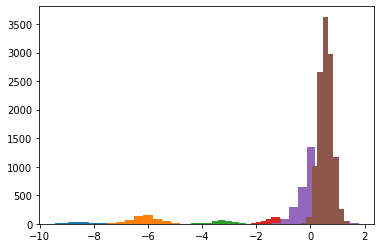

In [22]:
plt.hist(prova[0])
plt.hist(prova[1])
plt.hist(prova[2])
plt.hist(prova[3])
plt.hist(prova[4])
plt.hist(prova[5])
plt.hist(prova[6])
plt.show()

# VP012

In [23]:
file_pca = r.TFile("PCA_012.root", "RECREATE")

cond = " && k1>0 && k2>1"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()

In [54]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_012.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR0_av, track.VR1_av, track.VR2_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [55]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI4/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [56]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR0_av, track.VR1_av, track.VR2_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [57]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VR012")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_012")

381

In [58]:
kn = r.TCanvas()
pca_1.Draw("VR012>>012(100, -10, 5.5)")

hi = r.gDirectory.Get("012")
hi.SetTitle("VP_{012} (k_{1}>0 & k_{2}>1); VP_{012}; Entries")
hi.Draw("")

g2 = r.TF1("g2", "gaus(0) + gaus(3) + gaus(6)", -10.5, 6.)
g2.SetParameters(120, -.5, .5, 100, -2.7, 0.3, 40, -1.2, 0.5)
hi.Fit("g2", "L","", -10., -1.2)
#c.Update()
hi.Draw("PE")


t1 = r.TText(-9., 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

legend = r.TLegend(0.15,0.7,0.4,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("Entries", "Entries = " + str(hi.GetEntries()), "" )
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 4)), "")
legend.Draw("SAME")

kn.SetLogy(1)

kn.Draw()

 FCN=33.9425 FROM MIGRAD    STATUS=CONVERGED     583 CALLS         584 TOTAL
                     EDM=2.1385e-07    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   7.3 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           1.46162e+02   1.96126e+02   1.06445e+00  -6.70236e-05
   2  p1          -5.59197e-01   1.31004e+00   6.96464e-03   1.99751e-02
   3  p2           6.70140e-01   4.59524e-01   2.32360e-03  -2.94330e-02
   4  p3           1.13410e+02   6.23749e+00  -5.00298e-03  -6.47149e-06
   5  p4          -2.74458e+00   2.22702e-02  -4.72751e-05  -3.39187e-03
   6  p5           3.33453e-01   2.25067e-02  -3.90829e-05  -7.63001e-03
   7  p6           2.81960e+02   9.35804e+00  -6.27038e-04   3.71067e-07
   8  p7          -4.06247e+00   1.01065e-02   3.23009e-06  -9.53203e-05
   9  p8           3.22032e-01   7.93458e-03   2.47591e-06  -1.46027e-04
                              

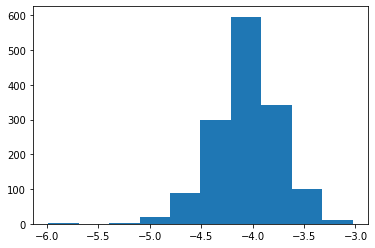

In [59]:
prova = make_classification_012(pca_1, g2, 3, -1.5)
plt.hist(prova[2])
#plt.hist(prova[2])
plt.show()

In [60]:
file_pca.Close()

In [61]:
prova2 = make_classification_012_X(pca_1, g2, file_name012, tup_name012, 3, -1.5, 2, 3, 4)

# VP013

In [62]:
file_pca = r.TFile("PCA_013.root", "RECREATE")

cond = " && k1>0 && k3>1"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()

In [63]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_013.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR0_av, track.VR1_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [64]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI4/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [65]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR0_av, track.VR1_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [66]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VR013")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_013")

370

In [67]:
kn = r.TCanvas()
pca_1.Draw("VR013>>013(100, -10, 5.5)")

hi = r.gDirectory.Get("013")
hi.SetTitle("VP_{013} (k_{1}>0 & k_{3}>1); VP_{013}; Entries")
hi.Draw("")

g2 = r.TF1("g2", "gaus(0) + gaus(3) + gaus(6)", -10.5, 6.)
g2.SetParameters(50, -6.5, .5, 50, -4.5, 0.5, 30, -2.5, 0.5)
hi.Fit("g2", "L","", -10., -2.)
#c.Update()
hi.Draw("PE")


t1 = r.TText(-9., 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")


legend = r.TLegend(0.15,0.7,0.4,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("Entries", "Entries = "+str(hi.GetEntries()), "" )
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 4)), "")
legend.Draw("SAME")

kn.SetLogy(1)

kn.Draw()

 FCN=21.1976 FROM MIGRAD    STATUS=CONVERGED     281 CALLS         282 TOTAL
                     EDM=6.70509e-07    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   2.8 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           3.68066e+01   2.99069e+00  -6.35616e-03   1.92487e-04
   2  p1          -6.36788e+00   4.27136e-02   2.65280e-04   7.10518e-03
   3  p2           4.30401e-01   3.12250e-02   1.41968e-04   3.79286e-03
   4  p3           7.66043e+01   4.30325e+00  -1.68278e-02   1.66150e-04
   5  p4          -4.60354e+00   2.56908e-02   2.61728e-04   1.77272e-02
   6  p5           4.74262e-01   2.73589e-02  -7.27517e-05   1.49861e-02
   7  p6           4.39040e+01   3.25036e+00   3.42717e-03  -1.22191e-04
   8  p7          -2.40228e+00   6.37252e-02   2.49715e-04   1.02160e-02
   9  p8           5.24449e-01   6.01436e-02   2.77231e-04  -1.49470e-02
                             

In [68]:
file_pca = r.TFile("PCA_013.root", "READ")
info_pca = file_pca.Get("pca")

pca_1.AddFriend(info_pca)

In [69]:
def make_classification_013_X(PCA_tup, fit_func, file_name, tupname, N_gaus=4, tr=-1.5, Z0=2, Z1=3, Z2=4): 
    
    params = fit_func.GetParameters()
    file_pca2 = r.TFile(file_name, "RECREATE")
    low_value, high_value = 0., 0.
    
    pca_2 = r.TNtuple(tupname, "", "VR012:Z_013")
    Z_c = 0.
    cn_s = []
    for i in range(N_gaus+1):
        cn_s.append([])
        
    for track in PCA_tup:
        PCA_value = track.VR013
        
        if (PCA_value>tr):
            cn_s[-1].append(PCA_value)
            Z_c = 11
            pca_2.Fill(PCA_value, Z_c)
            continue
        
        random_number = np.random.uniform(0,1)
        probs = []
        for i in range(N_gaus):
            probs.append(g_func(PCA_value, params[0+int(3*i)], params[1+int(3*i)], params[2+int(3*i)])/fit_func.Eval(PCA_value) )
        o_ps = sorted(probs)
        indexes = []
        for p in probs:
            indexes.append(o_ps.index(p))
        
        if (random_number <= o_ps[0]):
            check = True
            pos = 0
            for j1 in range(len(indexes)):
                if (indexes[j1] == 0): 
                    pos = j1
            for j2 in range(len(indexes)):
                if (j2 != pos and indexes[j2] == 0):
                    check = False
            if (check):
                cn_s[pos].append(PCA_value)
                if (pos == 0):
                    Z_c = Z0
                elif (pos == 1):
                    Z_c = Z1
                elif (pos == 2):
                    Z_c = Z2
                
                
        for k in range(N_gaus-1):
            
            if (k == 0):
                low_value = o_ps[0]
            elif (k == 1):
                low_value = o_ps[0] + o_ps[k]
            elif (k == 2):
                low_value = high_value
            high_value = low_value + o_ps[k+1]
        
            if (k < N_gaus-2):
                if (random_number > low_value and random_number <= high_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 0):
                    	    Z_c = Z0
                        elif (pos == 1):
                            Z_c = Z1
                        elif (pos == 2):
                            Z_c = Z2
                
            elif (k == N_gaus-2):  #funziona per N_gaus = 4
                if (random_number > low_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 0):
                            Z_c = Z0
                        elif (pos == 1):
                            Z_c = Z1
                        elif (pos == 2):
                            Z_c = Z2
    
        
        pca_2.Fill(PCA_value, Z_c)     
    pca_2.Write(tupname)
    file_pca2.Close()
    return cn_s

In [70]:
prova2 = make_classification_013_X(pca_1, g2, file_name013, tup_name013, 3, -1.5, 2, 3, 4)

# VP01

In [71]:
c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>Z1_2v", frag_cut + " && k2<2 && k3<2 && k1>0 && VR1_av<7500", "colz")

z12 = r.gDirectory.Get("Z1_2v")
z12.SetTitle("VR1_{av} vs VR0_{av} [Lower Population];VR0_{av};VR1_{av}")
z12.Draw("COLZ")

x0, y0 = 11000, 3600
x1, y1 = 12300, 3250
b = (y1-y0)/(x1-x0)
a = y0-b*x0
cut_expr = str(a) + " " + str(b) + "*x"

cut = r.TF1("cut_eli", cut_expr, 9200, 15000)
cut.SetLineColor(2)
cut.SetLineWidth(5)
cut.SetLineStyle(2)
cut.Draw("SAME")

t1 = r.TText(6000, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [72]:
c = r.TCanvas()

below = "VR1_av < " + str(a) + " + " + str(b) + "* VR0_av" 
above = "VR1_av >= " + str(a) + " + " + str(b) + "* VR0_av" 

tracks_2.Draw("tan>>z1(100,0,1)", below + " && k1>0 && k2<2 && k3<2 && VR1_av<7500 && " + frag_cut, "colz")

h1 = r.gDirectory.Get("z1")
h1.SetTitle("tan(#theta) [Below Cut]; tan(#theta);Entries")

t1 = r.TText(0.8, 20, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [73]:
c = r.TCanvas()
tracks_2.Draw("tan>>z2(100,0,1)", above + " && k1>0 && k2<2 && k3<2 && VR1_av<7500", "colz")

h1 = r.gDirectory.Get("z2")
h1.SetTitle("tan(#theta) [Above Cut]; tan(#theta);Entries")

t1 = r.TText(0.6, 250, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [74]:
file_pca = r.TFile("PCA_01.root", "RECREATE")

frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"

cond = " && k1>0 && k2<2 && k3<2 && VR1_av<7500"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()

In [75]:
principal = r.TPrincipal(2, "ND")

file_pca = r.TFile("PCA_01.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1 = track.VR0_av, track.VR1_av
    vrs = np.zeros(2)
    vrs[0] = vr0
    vrs[1] = vr1
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [76]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI4/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [77]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3 = track.VR0_av, track.VR1_av
    vrs = np.zeros(2)
    vrs[0] = vr2
    vrs[1] = vr3
    princ = np.zeros(2)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [78]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VP01")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_01")

351

In [79]:
kn = r.TCanvas()
pca_1.Draw("VP01>>01(90, -6.5, 5.5)")

hi = r.gDirectory.Get("01")
hi.SetTitle("VP_{01} [Lower Population]; VP_{01}; Entries")
hi.Draw("")
print(hi.GetEntries())

g2 = r.TF1("g2", "gaus(0) + gaus(3)", -6.5, 6.)
g2.SetParameters(400, 0.47, .6, 30, -2, 1.)

g2.SetParLimits(1, 0.2, .4)
g2.SetParLimits(4, -1.9, -1.8)

hi.Fit("g2", "S","", -5, 4.)
c.Update()
hi.Draw("PE")

params = g2.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp1_2 = r.TF1("comp1_2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1_2.SetParameters(params[3], params[4], params[5])
comp1_2.SetLineColor(2)
comp1_2.SetLineStyle(2)
comp1_2.Draw("SAME")


legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 10)), "")
legend.Draw("SAME")

t1 = r.TText(0.8, 20, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

kn.Draw()

5906.0
 FCN=125.943 FROM MIGRAD    STATUS=CONVERGED     156 CALLS         157 TOTAL
                     EDM=5.66159e-07    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   5.3 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           3.69701e+02   7.63846e+00   1.46703e-02  -3.41218e-05
   2  p1           3.07221e-01   1.63328e-02  -1.39774e-03  -3.19933e-03
   3  p2           6.95888e-01   1.44415e-02   4.28800e-05   6.95470e-02
   4  p3           5.27739e+01   2.91739e+00  -8.58666e-03   5.28857e-04
   5  p4          -1.87000e+00   5.10153e-02  -2.08257e-02   1.39897e-04
   6  p5           9.39493e-01   6.20205e-02  -4.99875e-04   3.19846e-03


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [80]:
prova = make_classification_01_X(pca_1, g2, '01.root', '01_c')

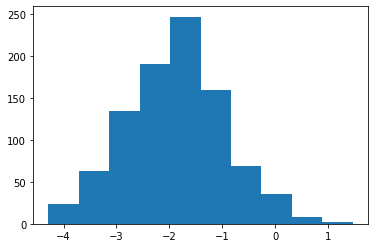

In [81]:
plt.hist(prova[1])
#plt.hist(prova[1])
plt.show()

In [82]:
prova = make_classification_01_X(pca_1, g2, '01.root', '01_c', 2, 1)

# Scrittura Z in Output

In [83]:
file = r.TFile(track_name, "READ")
tracks = file.Get("tracks")

In [84]:
## Definizione tree in uscita

file_out = r.TFile(outname, "RECREATE")

Z_rec = np.zeros(1, dtype = np.intc)

output_tree = tracks.CloneTree(0)

#tracks.SetBranchAddress("n0", Z_rec)
output_tree.Branch("Z", Z_rec, "Z/I")

tracks.BuildIndex("trid")

124802

In [85]:
## tree con variabili di volume

nseg0 = np.zeros(1, dtype = np.intc)
nseg1 = np.zeros(1, dtype = np.intc)
nseg2 = np.zeros(1, dtype = np.intc)
nseg3 = np.zeros(1, dtype = np.intc)

volume0 = np.zeros(1, dtype = np.double)
volume1 = np.zeros(1, dtype = np.double)
volume2 = np.zeros(1, dtype = np.double)
volume3 = np.zeros(1, dtype = np.double)


output_tree2 = tracks.CloneTree(0)
output_tree2.Branch("VR0_av", volume0, "VR0_av/D")
output_tree2.Branch("VR1_av", volume1, "VR1_av/D")
output_tree2.Branch("VR2_av", volume2, "VR2_av/D")
output_tree2.Branch("VR3_av", volume3, "VR3_av/D")

output_tree2.Branch("k0", nseg0, "k0/I")
output_tree2.Branch("k1", nseg1, "k1/I")
output_tree2.Branch("k2", nseg2, "k2/I")
output_tree2.Branch("k3", nseg3, "k3/I")

output_tree2.Branch("Z", Z_rec, "Z/I")


In [86]:
for i in range(tracks.GetEntries()):
    tracks.GetEntry(i)
    k0, k1, k2, k3 = 0, 0, 0, 0
    VR0av, VR1av, VR2av, VR3av = 0, 0, 0, 0
    vr0, vr1, vr2, vr3 = 0, 0, 0, 0
    for s in tracks.s:
        if((s.Plate()-31)%4 - 0 == 0):
            k0+=1
            vr0 += s.Volume()
        if((s.Plate()-31)%4 - 1 == 0):
            k1+=1
            vr1 += s.Volume()   
        if((s.Plate()-31)%4 - 2 == 0):
            k2+=1
            vr2 += s.Volume()
        if((s.Plate()-31)%4 - 3 == 0):
            k3+=1
            vr3 += s.Volume()      
    if(k0!=0):
            VR0av = vr0/k0
    if(k1!=0):
            VR1av = vr1/k1
    if(k2!=0):
            VR2av = vr2/k2
    if(k3!=0):
            VR3av = vr3/k3
            
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = k0, k1, k2, k3
    volume0[0], volume1[0], volume2[0], volume3[0] = VR0av, VR1av, VR2av, VR3av
    
    if (k0<k0_min or VR0av>=VR0_max):
        Z_rec[0] = -1
        
        output_tree.Fill()
        output_tree2.Fill()

In [87]:
count = 0
g1, g2, g3, g4, g5, g6, g7 = 0, 0, 0, 0, 0, 0, 0
for i in range(tracks_2.GetEntries()):
    tracks_2.GetEntry(i)
    tracks.GetEntry(tracks_2.trid)
    frag_cut = (tracks_2.VR0_av > a2*(1 + np.exp(b2 * tracks_2.tan*tracks_2.tan)))
    cond1 = (tracks_2.k2 <=1 and tracks_2.k3<=1)
    cond2 = tracks_2.VR1_av>0
    cond3 = tracks_2.VR1_av>6000
    cond0 = tracks_2.VR1_av == 0
    cond4 = tracks_2.k2 == 0
    cond_vp123 = tracks_2.k1>0 and tracks_2.k2>1 and tracks_2.k3>1
    cond_vp012 = tracks_2.k1>0 and tracks_2.k2>1 and tracks_2.k3<=1
    cond_vp013 = tracks_2.k1>0 and tracks_2.k2<=1 and tracks_2.k3>1
    
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
    volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
    
    if ((i%10000)==0):
        print("Carica Assegnata a " + str(round(count,2)) + " tracce, su " + str(tracks_2.GetEntries()))
    if (frag_cut and cond0):
        Z_rec[0] = 1
        output_tree.Fill()
        output_tree2.Fill()
        count = count + 1
        g1 = g1 + 1
    elif (frag_cut and cond1 and cond2 and tracks_2.VR1_av<7500):
        #Z_rec[0] = 2
        #print("Z= "+str(Z_rec))
        #output_tree.Fill()
        #count = count + 1
        g2 = g2 + 1 
        continue
    elif (frag_cut and cond1 and cond2 and tracks_2.VR1_av>7500):
        Z_rec[0] = 11 
        #print("Z= "+str(Z_rec))
        output_tree.Fill()
        output_tree2.Fill()
        count = count + 1
        g3 = g3 +1
    #elif (frag_cut and cond4 and cond2):
        #Z_rec[0] = 1
        #output_tree.Fill()
        #count = count + 1
    elif (not frag_cut):
        Z_rec[0] = -1
        #print("Z=" +str(Z_rec))
        output_tree.Fill()
        output_tree2.Fill()
        count = count + 1
        g4 = g4 + 1
    elif (cond_vp123):
        g5 = g5 + 1
        continue
    elif (cond_vp012):
        g6 = g6 + 1
        continue
    elif (cond_vp013):
        g7 = g7 +1
        continue
    else:
        Z_rec[0] = 10
        output_tree.Fill()
        output_tree2.Fill()
    if (count == 0):
        print("Errore")
    #print("count= " + str(count))
print(g1, g2, g3, g4, g5 ,g6, g7)   

Carica Assegnata a 0 tracce, su 76153
Carica Assegnata a 7222 tracce, su 76153
Carica Assegnata a 13639 tracce, su 76153
Carica Assegnata a 19579 tracce, su 76153
Carica Assegnata a 24810 tracce, su 76153
Carica Assegnata a 29172 tracce, su 76153
Carica Assegnata a 37995 tracce, su 76153
Carica Assegnata a 47238 tracce, su 76153
22800 5906 80 30281 15246 1639 201


In [88]:
file_pca01 = r.TFile(file_name01, "READ")
pca_3 = file_pca01.Get(tup_name01)

file_info_pca01 = r.TFile("PCA_01.root", "READ")
info_pca01 = file_info_pca01.Get("pca")

pca_3.AddFriend(info_pca01)
tracks_2.BuildIndex("trid", "npl")
count2 = 0
m1, m2 = 0, 0

for track_123 in pca_3:
    
    trid_to_assign, npl_to_assign = track_123.trid, track_123.npl
    tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
    tracks.GetEntry(tracks_2.trid)
    
    #check0 = track_123.k2>1 and track_123.k3>1
    check1 = track_123.tan == tracks_2.tan and track_123.k0 == tracks_2.k0 and track_123.VR0_av == tracks_2.VR0_av
    check2 = track_123.k1 == tracks_2.k1 and track_123.VR1_av == tracks_2.VR1_av
    check3 = track_123.k2 == tracks_2.k2 and track_123.VR2_av == tracks_2.VR2_av
    check4 = track_123.k3 == tracks_2.k3 and track_123.VR3_av == tracks_2.VR3_av
    check5 = track_123.nseg == tracks_2.nseg and track_123.npl == tracks_2.npl
    check = check1 and check2 and check3 and check4 and check5
    
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
    volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
    
    if (check):
        if (int(track_123.Z_c == 1)):
            Z_rec[0] = 2 #sono invertiti in questa classificazione
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            m2 = m2 + 1
            count2 = count2 +1
        elif(int(track_123.Z_c == 2) ):
            Z_rec[0] = 1  #sono invertiti in questa classificazione
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            m1 = m1 +1 
            count2 = count2 +1
    #if (count == 0):
        #print("Error")
        #break
    
    if (count2%1000 == 0):
        print("Carica assegnata a " + str(count2+count) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca01.Close()
file_info_pca01.Close()
print("100%")
print(count2)
print(m1, m2)

Carica assegnata a 54161 tracce, su 76153
Carica assegnata a 55161 tracce, su 76153
Carica assegnata a 56161 tracce, su 76153
Carica assegnata a 57161 tracce, su 76153
Carica assegnata a 58161 tracce, su 76153
100%
5906
959 4947


In [89]:
file_pca123 = r.TFile(file_name123, "READ")
pca_3 = file_pca123.Get(tup_name123)

file_info_pca123 = r.TFile("PCA_123.root", "READ")
info_pca123 = file_info_pca123.Get("pca")

pca_3.AddFriend(info_pca123)
tracks_2.BuildIndex("trid", "npl")
count3 = 0

for track_123 in pca_3:
    
    trid_to_assign, npl_to_assign = track_123.trid, track_123.npl
    tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
    tracks.GetEntry(tracks_2.trid)
    
    check0 = track_123.k2>1 and track_123.k3>1
    check1 = track_123.tan == tracks_2.tan and track_123.k0 == tracks_2.k0 and track_123.VR0_av == tracks_2.VR0_av
    check2 = track_123.k1 == tracks_2.k1 and track_123.VR1_av == tracks_2.VR1_av
    check3 = track_123.k2 == tracks_2.k2 and track_123.VR2_av == tracks_2.VR2_av
    check4 = track_123.k3 == tracks_2.k3 and track_123.VR3_av == tracks_2.VR3_av
    check5 = track_123.nseg == tracks_2.nseg and track_123.npl == tracks_2.npl
    check = check1 and check2 and check3 and check4 and check5 and check0
    
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
    volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
    
    if (check):
        Z_rec[0] = int(track_123.Z_c)
        #print(Z_rec)
        output_tree.Fill()
        output_tree2.Fill()
        count3 = count3 +1
    #if (count == 0):
        #print("Error")
        #break
    
    if (count3%1000 == 0):
        print("Carica assegnata a " + str(count2+count+count3) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca123.Close()
file_info_pca123.Close()
print("100%")
print(count3)

Carica assegnata a 60067 tracce, su 76153
Carica assegnata a 61067 tracce, su 76153
Carica assegnata a 62067 tracce, su 76153
Carica assegnata a 63067 tracce, su 76153
Carica assegnata a 64067 tracce, su 76153
Carica assegnata a 65067 tracce, su 76153
Carica assegnata a 66067 tracce, su 76153
Carica assegnata a 67067 tracce, su 76153
Carica assegnata a 68067 tracce, su 76153
Carica assegnata a 69067 tracce, su 76153
Carica assegnata a 70067 tracce, su 76153
Carica assegnata a 71067 tracce, su 76153
Carica assegnata a 72067 tracce, su 76153
Carica assegnata a 73067 tracce, su 76153
Carica assegnata a 74067 tracce, su 76153
100%
15246


In [90]:
file_pca012 = r.TFile(file_name012, "READ")
pca_012 = file_pca012.Get(tup_name012)

file_info_pca012 = r.TFile("PCA_012.root", "READ")
info_pca012 = file_info_pca012.Get("pca")

pca_012.AddFriend(info_pca012)
#tracks_2.BuildIndex("trid", "npl")
count4 = 0

for track_012 in pca_012:
    
    countx = 0
    if (track_012.k2 > 1 and track_012.k3<=1):
        trid_to_assign, npl_to_assign = track_012.trid, track_012.npl
        tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
        tracks.GetEntry(tracks_2.trid)
    
        check1 = track_012.tan == tracks_2.tan and track_012.k0 == tracks_2.k0 and track_012.VR0_av == tracks_2.VR0_av
        check2 = track_012.k1 == tracks_2.k1 and track_012.VR1_av == tracks_2.VR1_av
        check3 = track_012.k2 == tracks_2.k2 and track_012.VR2_av == tracks_2.VR2_av
        check4 = track_012.k3 == tracks_2.k3 and track_012.VR3_av == tracks_2.VR3_av
        check5 = track_012.nseg == tracks_2.nseg and track_012.npl == tracks_2.npl
        check = check1 and check2 and check3 and check4 and check5
        
        nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
        volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
        
        if (check and track_012.VR2_av < 8000):
            Z_rec[0] = int(track_012.Z_012) 
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            countx = countx + 1
            count4 = count4 +1
        elif (check and track_012.VR2_av > 8000):
            Z_rec[0] = 11
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            countx = countx + 1
            count4 = count4 +1
        #if (count == 0):
            #print("Error")
            #break
        
        if (count4%100 == 0):
           print("Carica assegnata a " + str(count2+count+count3+count4) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca012.Close()
file_info_pca012.Close()
print("100%")
print(count4)

Carica assegnata a 74413 tracce, su 76153
Carica assegnata a 74513 tracce, su 76153
Carica assegnata a 74613 tracce, su 76153
Carica assegnata a 74713 tracce, su 76153
Carica assegnata a 74813 tracce, su 76153
Carica assegnata a 74913 tracce, su 76153
Carica assegnata a 75013 tracce, su 76153
Carica assegnata a 75113 tracce, su 76153
Carica assegnata a 75213 tracce, su 76153
Carica assegnata a 75313 tracce, su 76153
Carica assegnata a 75413 tracce, su 76153
Carica assegnata a 75513 tracce, su 76153
Carica assegnata a 75613 tracce, su 76153
Carica assegnata a 75713 tracce, su 76153
Carica assegnata a 75813 tracce, su 76153
Carica assegnata a 75913 tracce, su 76153
100%
1639


In [91]:
print(count+count2+count3+count4)
print(tracks_2.GetEntries())

75952
76153


In [92]:
file_pca013 = r.TFile(file_name013, "READ")
pca_013 = file_pca013.Get(tup_name013)

file_info_pca013 = r.TFile("PCA_013.root", "READ")
info_pca013 = file_info_pca013.Get("pca")

pca_013.AddFriend(info_pca013)
#tracks_2.BuildIndex("trid", "npl")
count5 = 0

for track_012 in pca_013:
    
    if (track_012.k3 > 1 and track_012.k2<=1):
        trid_to_assign, npl_to_assign = track_012.trid, track_012.npl
        tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
        tracks.GetEntry(tracks_2.trid)
    
        check1 = track_012.tan == tracks_2.tan and track_012.k0 == tracks_2.k0 and track_012.VR0_av == tracks_2.VR0_av
        check2 = track_012.k1 == tracks_2.k1 and track_012.VR1_av == tracks_2.VR1_av
        check3 = track_012.k2 == tracks_2.k2 and track_012.VR2_av == tracks_2.VR2_av
        check4 = track_012.k3 == tracks_2.k3 and track_012.VR3_av == tracks_2.VR3_av
        check5 = track_012.nseg == tracks_2.nseg and track_012.npl == tracks_2.npl
        check = check1 and check2 and check3 and check4 and check5
        
        nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
        volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
        
        if (check):
            Z_rec[0] = int(track_012.Z_013)
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            count5 = count5 +1
        elif (check and track_012.VR2_av > 10000):
            Z_rec[0] = 11
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            count5 = count5 +1
        #if (count == 0):
            #print("Error")
            #break
        
        #if (count5%100 == 0):
           #print("Carica assegnata a " + str(count2+count+count3+count4+count5) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca013.Close()
file_info_pca013.Close()
print("100%")
print(count5)

100%
201


In [93]:
file_out.cd()
#output_tree.Write("tracks")
output_tree2.Write("tracks")   #con info su VRi_av e ki
file_out.Close()

# Plot Opzionali

In [94]:
file_out2 = r.TFile(outname, "READ")
output_tree = file_out2.Get("tracks")

output_tree.Draw("s[0].Theta()>>Z10(50)", "Z > 0 && Z<10")
h4 = r.gDirectory.Get("Z10")
N2 = h4.GetEntries()
print(N2)

45440.0


In [95]:
c = r.TCanvas()

output_tree.Draw("s[0].Theta()>>Z1n(100, 0, 1)", "Z == 1")
hs = r.THStack("h4s", "")
h1n = r.gDirectory.Get("Z1n")
h1n.SetFillColor(0)
h1n.SetLineWidth(2)
h1n.SetLineColor(1)
hs.Add(h1n)

output_tree.Draw("s[0].Theta()>>Z2n(100, 0, 1)", "Z == 2")
h2n = r.gDirectory.Get("Z2n")
h2n.SetFillColor(0)
h2n.SetLineWidth(2)
h2n.SetLineColor(4)
hs.Add(h2n)

output_tree.Draw("s[0].Theta()>>Z3n(100, 0, 1)", "Z == 3")
h3n = r.gDirectory.Get("Z3n")
h3n.SetFillColor(0)
h3n.SetLineWidth(2)
h3n.SetLineColor(95)
hs.Add(h3n)

output_tree.Draw("s[0].Theta()>>Z4n(100, 0, 1)", "Z == 4")
h4n = r.gDirectory.Get("Z4n")
h4n.SetFillColor(0)
h4n.SetLineWidth(2)
h4n.SetLineColor(8)
hs.Add(h4n)

output_tree.Draw("s[0].Theta()>>Z5n(100, 0, 1)", "Z == 5")
h5n = r.gDirectory.Get("Z5n")
h5n.SetFillColor(0)
h5n.SetLineWidth(2)
h5n.SetLineColor(r.kPink+3)
hs.Add(h5n)

hs.SetTitle("Fragments Angular Distribution " + str(brick_id) + " (k_{0}>=" + str(k0_min)+"); tan(#theta); Entries")
hs.Draw("nostack")

legend = r.TLegend(0.55,0.6,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)

def lazy(histo, N):
    return "Entries = "+str(histo.GetEntries()) + " (" + str(round(100*histo.GetEntries()/N, 1)) + "%)}{Mean: "+ str(round(histo.GetMean(), 2)) + ", RMS = "+str(round(histo.GetRMS(),2))+"}"

#N = 34881.0

legend.AddEntry(h1n, "#splitline{Z=1, " + lazy(h1n, N2))
legend.AddEntry(h2n, "#splitline{Z=2, "+ lazy(h2n, N2))
legend.AddEntry(h3n, "#splitline{Z=3, "+ lazy(h3n, N2))
legend.AddEntry(h4n, "#splitline{Z=4, "+ lazy(h4n, N2))
legend.AddEntry(h5n, "#splitline{Z=5, "+ lazy(h5n, N2))
legend.Draw("SAME")

c.Draw()